In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay

In [158]:
def report(y_true,y_pred):
    report = classification_report(y_true,y_pred)
    conf_matrix = confusion_matrix(y_true,y_pred)
    disp = ConfusionMatrixDisplay(conf_matrix)
    disp.plot()
    print(report)

In [159]:
def model_training(list_of_models,X_train,y_train,X_test,y_test):
    for model in list_of_models:
        model.fit(X_train,y_train)
        y_pred = model.predict(X_test)
        print(f"Model: {model.__class__.__name__}")
        report(y_test,y_pred)


In [160]:
df = pd.read_csv('TCA_Cleaned.csv')

In [161]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked,Title
419,420,0,3,"Van Impe, Miss. Catharina",female,10.0,3,345773,24.1500,S,Miss
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,2,11767,83.1583,C,Mrs
534,535,0,3,"Cacic, Miss. Marija",female,30.0,1,315084,8.6625,S,Miss
758,759,0,3,"Theobald, Mr. Thomas Leonard",male,34.0,1,363294,8.0500,S,Mr
522,523,0,3,"Lahoud, Mr. Sarkis",male,NaN,1,2624,7.2250,C,Mr


In [162]:
df["Age"] = df["Age"].fillna(
    df.groupby(["Sex", "Pclass"])["Age"].transform("median")
)

In [163]:
df['Age'].isnull().sum()

np.int64(0)

In [164]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
FamSize        0
Ticket         0
Fare           0
Embarked       2
Title          1
dtype: int64

In [165]:
df.dropna(inplace=True)

In [166]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
FamSize        0
Ticket         0
Fare           0
Embarked       0
Title          0
dtype: int64

In [167]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked,Title
584,585,0,3,"Paulner, Mr. Uscher",male,25.0,1,3411,8.7125,C,Mr
295,296,0,1,"Lewy, Mr. Ervin G",male,40.0,1,PC 17612,27.7208,C,Mr
585,586,1,1,"Taussig, Miss. Ruth",female,18.0,3,110413,79.6500,S,Miss
713,714,0,3,"Larsson, Mr. August Viktor",male,29.0,1,7545,9.4833,S,Mr
232,233,0,2,"Sjostedt, Mr. Ernst Adolf",male,59.0,1,237442,13.5000,S,Mr


## Using StandardScaler on age and Fare columns
## OneHotencoding the sex,Title and embarked columns

In [168]:
numerical_features = ['Age', 'Fare']
scaler = StandardScaler()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,2,A/5 21171,7.2500,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,2,PC 17599,71.2833,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,1,STON/O2. 3101282,7.9250,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,2,113803,53.1000,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,1,373450,8.0500,S,Mr


In [169]:
df['Title'].value_counts()

Title
Mr          517
Miss        181
Mrs         124
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Don           1
Mme           1
Ms            1
Sir           1
Lady          1
Capt          1
Jonkheer      1
Name: count, dtype: int64

In [170]:
categorical_features = ['Sex', 'Embarked', 'Title']
Sex = {'male':0,"female":1}
embarked = {'S':0,'C':1,'Q':2}
title = {'Mr':0,'Miss':1,'Mrs':2,'Master':3,'Other':4}
def map_values(value):
    value['Sex'] = Sex[value['Sex']]
    value['Embarked'] = embarked[value['Embarked']]
    try: 
        value['Title'] = title[value['Title']]
    except KeyError: 
        if value['Title'] == 'Mme':
            value['Title'] = 2
        elif value['Title'] == 'Don' or value['Title'] == 'Jonkheer':
            value['Title'] = 3
        elif value['Title'] == 'Mlle' or value['Title'] == 'Ms':
            value['Title'] = 1
        else:
            value['Title'] = 4
    return value
df[['Sex','Embarked','Title']] = df[['Sex','Embarked','Title']].apply(map_values, axis=1)

In [171]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,2,A/5 21171,7.2500,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,2,PC 17599,71.2833,1,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,1,STON/O2. 3101282,7.9250,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,2,113803,53.1000,0,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,1,373450,8.0500,0,0


In [172]:
xgbModel = XGBClassifier()
svmModel = SVC(kernel='linear',probability=True)
list_of_models = [xgbModel,svmModel]
x = df.drop(columns=['Survived','Name','Ticket','PassengerId'], axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.15,random_state=42)
scaler.fit_transform(X_train[numerical_features])
scaler.transform(X_test[numerical_features])

array([[-0.0925599 , -0.49945724],
       [-1.13420414,  1.81011419],
       [-1.13420414, -0.42969383],
       [ 0.05624642, -0.39348276],
       [-0.8365915 ,  0.9791316 ],
       [ 0.13064958, -0.50108831],
       [-0.31576938, -0.39348276],
       [-0.31576938, -0.49542486],
       [ 0.72587486,  1.62236155],
       [ 0.05624642,  1.5305457 ],
       [-0.57618044,  0.77112852],
       [-0.39017254, -0.33478882],
       [ 1.61871279, -0.51593273],
       [-0.24136622, -0.36353443],
       [-0.01815674, -0.46590696],
       [-0.0925599 , -0.19732144],
       [ 1.54430963,  1.5305457 ],
       [-0.31576938, -0.51232871],
       [ 1.0234875 , -0.52837584],
       [-0.31576938, -0.49860051],
       [-0.98539782,  0.30466618],
       [ 0.42826222,  0.47148053],
       [ 0.94908434, -0.48813034],
       [ 0.80027802, -0.09031724],
       [-0.31576938, -0.49542486],
       [ 0.80027802, -0.09031724],
       [ 0.50266538, -0.39605705],
       [-0.0925599 , -0.40686909],
       [ 0.80027802,

In [173]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((754, 7), (754,), (134, 7), (134,))

In [174]:
X_train.columns

Index(['Pclass', 'Sex', 'Age', 'FamSize', 'Fare', 'Embarked', 'Title'], dtype='object')

Model: XGBClassifier
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        90
           1       0.74      0.77      0.76        44

    accuracy                           0.84       134
   macro avg       0.81      0.82      0.82       134
weighted avg       0.84      0.84      0.84       134

Model: SVC
              precision    recall  f1-score   support

           0       0.90      0.80      0.85        90
           1       0.67      0.82      0.73        44

    accuracy                           0.81       134
   macro avg       0.78      0.81      0.79       134
weighted avg       0.82      0.81      0.81       134



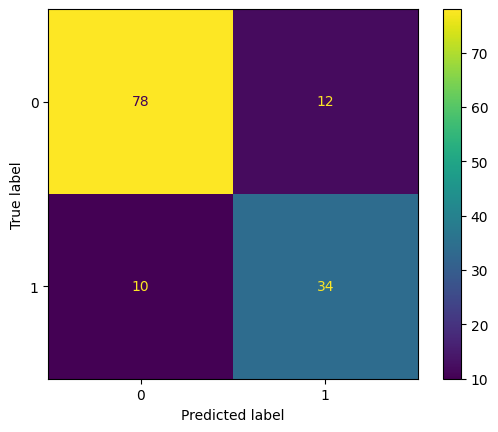

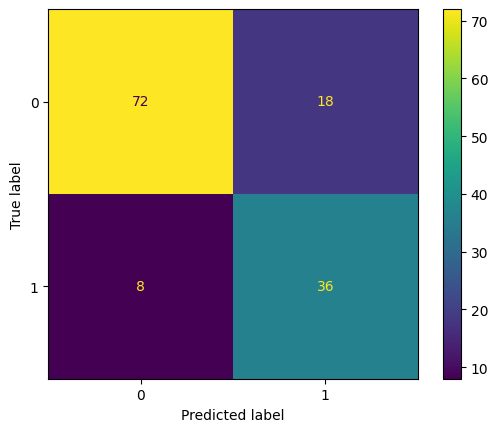

In [175]:
model_training(list_of_models,X_train,y_train,X_test,y_test)

In [176]:
xgbFI = xgbModel.feature_importances_
svmFI = svmModel.coef_[0]

In [177]:
columns = X_train.columns

Text(0.5, 1.0, 'SVM Feature Importance')

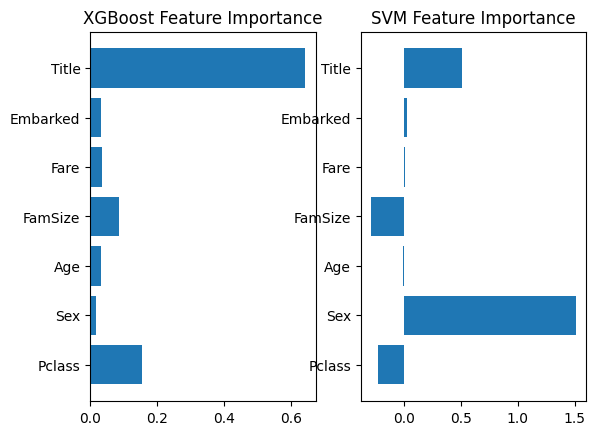

In [178]:
ax = plt.subplot(1,2,1)
ax.barh(columns,xgbFI)
ax.set_title("XGBoost Feature Importance")
ax = plt.subplot(1,2,2)
ax.barh(columns,svmFI)
ax.set_title("SVM Feature Importance")

In [179]:
X_train = df.drop(columns=['Survived','Name','Ticket','PassengerId'], axis=1)
y_train = df['Survived']
scaler.fit_transform(X_train[numerical_features])

array([[-0.5318471 , -0.4990628 ],
       [ 0.67410304,  0.79026952],
       [-0.23035956, -0.48547144],
       ...,
       [-0.56953304, -0.17287027],
       [-0.23035956, -0.04098379],
       [ 0.22187174, -0.48899513]], shape=(888, 2))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98        90
           1       0.98      0.95      0.97        44

    accuracy                           0.98       134
   macro avg       0.98      0.97      0.97       134
weighted avg       0.98      0.98      0.98       134



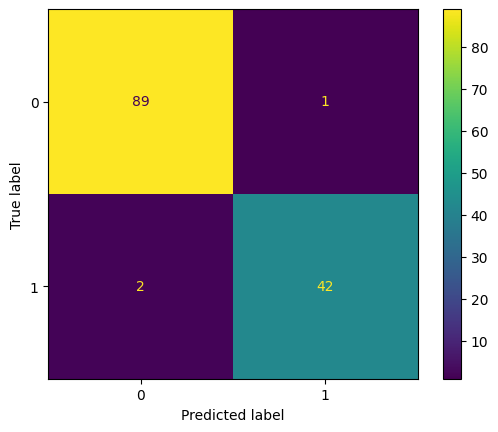

In [180]:
model = XGBClassifier()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
report(y_test,y_pred)

In [181]:
test_data = pd.read_csv('test.csv')

In [182]:
test_data.sample(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
86,978,3,"Barry, Miss. Julia",female,27.0,0,0,330844,7.8792,NaN,Q
320,1212,3,"Andersson, Mr. Johan Samuel",male,26.0,0,0,347075,7.7750,NaN,S
228,1120,3,"Everett, Mr. Thomas James",male,40.5,0,0,C.A. 6212,15.1000,NaN,S
387,1279,2,"Ashby, Mr. John",male,57.0,0,0,244346,13.0000,NaN,S
322,1214,2,"Nesson, Mr. Israel",male,26.0,0,0,244368,13.0000,F2,S


In [183]:
test_data['Age'] = test_data['Age'].fillna(
    test_data.groupby(["Sex", "Pclass"])["Age"].transform("median")
)

In [184]:
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].mean())

In [185]:
test_data.drop('Cabin',axis=1,inplace=True)

In [186]:
test_data.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [187]:
test_data["FamSize"] = test_data["SibSp"] + test_data["Parch"] + 1
test_data.drop(columns=['SibSp','Parch','Ticket'],inplace=True)
test_data.sample(2)

,PassengerId,Pclass,Name,Sex,Age,Fare,Embarked,FamSize
362,1254,2,"Ware, Mrs. John James (Florence Louise Long)",female,31.0,21.00,S,1
396,1288,3,"Colbert, Mr. Patrick",male,24.0,7.25,Q,1


In [188]:
test_data["Title"] = test_data["Name"].str.extract(r", (\w+)\.")

In [189]:
test_data.sample(2)

,PassengerId,Pclass,Name,Sex,Age,Fare,Embarked,FamSize,Title
142,1034,1,"Ryerson, Mr. Arthur Larned",male,61.0,262.375,C,5,Mr
256,1148,3,"Mahon, Mr. John",male,24.0,7.750,Q,1,Mr


In [190]:
test_data[numerical_features] = scaler.transform(test_data[numerical_features])
test_data[['Sex','Embarked','Title']] = test_data[['Sex','Embarked','Title']].apply(map_values, axis=1)
test_data.sample(2)

,PassengerId,Pclass,Name,Sex,Age,Fare,Embarked,FamSize,Title
406,1298,2,"Ware, Mr. William Jeffery",0,-0.456475,-0.433623,0,2,0
42,934,3,"Goldsmith, Mr. Nathan",0,0.900219,-0.486982,0,1,0


In [191]:
X_data = test_data[X_train.columns]

In [192]:
X_data

,Pclass,Sex,Age,FamSize,Fare,Embarked,Title
0,3,0,0.410301,1,-0.487400,2,0
1,3,1,1.352450,2,-0.504097,0,2
2,2,0,2.483028,1,-0.449983,2,0
3,3,0,-0.154988,1,-0.470622,0,0
4,3,1,-0.531847,3,-0.397631,0,2
...,...,...,...,...,...,...,...
413,3,0,-0.381103,1,-0.482955,0,0
414,1,1,0.749475,1,1.547695,1,4
415,3,0,0.711789,1,-0.499063,0,0
416,3,0,-0.381103,1,-0.482955,0,0


In [193]:
y_pred = model.predict(X_data)

In [194]:
final_submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': y_pred
})

In [195]:
final_submission.to_csv('Submission.csv',index=False)